# Visualising the Multifractal Nature of Speech — $h(q)$ Analysis

This notebook demonstrates **Multifractal Detrended Fluctuation Analysis (MFDFA)**
on speech signals and visualises the **generalised Hurst exponent** $h(q)$ for
healthy and pathological voice recordings.

**Key idea:** A monofractal signal has a constant $h(q)$ across all $q$-orders.
A *multifractal* signal has $h(q)$ that *varies* with $q$ — negative $q$ amplifies
small fluctuations while positive $q$ amplifies large ones. The degree of variation
($\Delta h = h(q_{\min}) - h(q_{\max})$) quantifies the **multifractal strength**
of the signal.

We show that speech — especially pathological speech — exhibits rich multifractal
behaviour, which motivates the use of MFDFA features for voice disorder classification.

## 1 — Setup & Imports

In [1]:
import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from MFDFA import MFDFA

# Project root for src imports
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PATHOLOGY_DE_TO_EN

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

print("Setup complete.")

Setup complete.


## 2 — MFDFA Parameters

**MFDFA** analyses how fluctuations in a signal scale across different time windows $s$ and
statistical moment orders $q$:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| $q$ range | $[-5, 5]$, step $0.5$ | Statistical moments — negative $q$ probes *small* fluctuations, positive $q$ probes *large* ones |
| Scales | 40 log-spaced values from 16 to $N/4$ | Window sizes for the detrending step |
| Polynomial order | 1 (linear) | Order of the local trend removed within each window |
| Sample rate | 50 kHz | Target sample rate for audio loading |

In [2]:
# ── MFDFA configuration ──────────────────────────────────────
Q_MIN, Q_MAX, Q_STEP = -5.0, 5.0, 0.5
MFDFA_ORDER = 1
NUM_SCALES = 40
TARGET_SR = 50_000

q_values = np.arange(Q_MIN, Q_MAX + Q_STEP / 2, Q_STEP)
print(f"q range: {q_values[0]:.1f} → {q_values[-1]:.1f}  ({len(q_values)} values)")
print(f"Polynomial order: {MFDFA_ORDER}")
print(f"Number of scales: {NUM_SCALES}")
print(f"Target sample rate: {TARGET_SR} Hz")

q range: -5.0 → 5.0  (21 values)
Polynomial order: 1
Number of scales: 40
Target sample rate: 50000 Hz


## 3 — Load Audio Samples

We load two sustained /a/ vowel recordings (token `a_n`) from the SVD dataset:

1. **Healthy** speaker — normal vocal function
2. **Pathological** speaker — recurrent laryngeal nerve paralysis (neurological voice disorder)

This pairing highlights how multifractal structure differs between healthy and disordered voice production.

In [3]:
DATA_ROOT = Path("..") / "data" / "processed" / "wav"

samples = {
    "Healthy": DATA_ROOT / "healthy" / "1" / "vowels" / "1-a_n.wav",
    "Recurrent Laryngeal\nNerve Paralysis": DATA_ROOT / "Rekurrensparese" / "105" / "vowels" / "105-a_n.wav",
}

signals = {}
for label, wav_path in samples.items():
    sig, sr = librosa.load(wav_path, sr=TARGET_SR, mono=True)
    # Peak-normalise to [-1, 1]
    max_abs = np.max(np.abs(sig))
    if max_abs > 0:
        sig = sig / max_abs
    signals[label] = sig
    dur = len(sig) / sr
    print(f"{label:40s}  samples={len(sig):,}  duration={dur:.2f}s  SR={sr} Hz")

Healthy                                   samples=97,418  duration=1.95s  SR=50000 Hz
Recurrent Laryngeal
Nerve Paralysis       samples=55,809  duration=1.12s  SR=50000 Hz


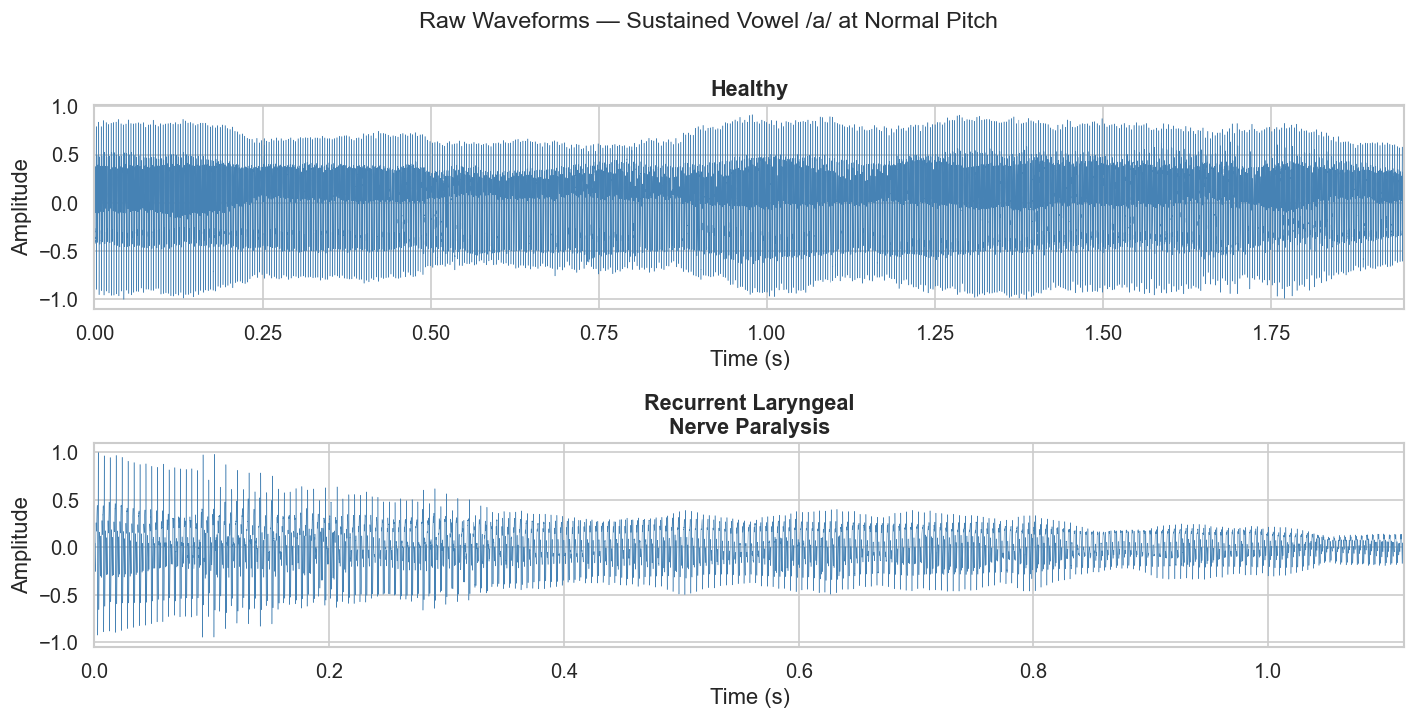

In [11]:
# ── Waveform comparison ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

for ax, (label, sig) in zip(axes, signals.items()):
    t = np.arange(len(sig)) / TARGET_SR
    ax.plot(t, sig, linewidth=0.3, color="steelblue")
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, t[-1])

fig.suptitle("Raw Waveforms — Sustained Vowel /a/ at Normal Pitch", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()


## 4 — Run MFDFA & Compute $h(q)$

We now run Multifractal Detrended Fluctuation Analysis on each signal:

1. **Compute** the fluctuation function $F_q(s)$ for each $q$ and window scale $s$
2. **Estimate** $h(q)$ as the slope of $\log F_q(s)$ vs $\log s$ (linear regression)
3. **Derive** the mass exponent $\tau(q) = q \cdot h(q) - 1$ and singularity spectrum via Legendre transform

In [5]:
def compute_scales(num_samples: int, num_scales: int) -> np.ndarray:
    """Log-spaced integer window scales from 16 to N/4."""
    min_scale, max_scale = 16, max(17, num_samples // 4)
    scales = np.unique(
        np.logspace(np.log10(min_scale), np.log10(max_scale), num=max(num_scales, 6)).astype(int)
    )
    return scales[scales > 1]


def estimate_hq(lags: np.ndarray, fq: np.ndarray) -> np.ndarray:
    """Estimate h(q) from MFDFA fluctuation output via log-log regression."""
    lags = np.asarray(lags, dtype=float)
    fq = np.asarray(fq, dtype=float)
    if fq.shape[0] != lags.shape[0] and fq.shape[1] == lags.shape[0]:
        fq = fq.T
    log_lags = np.log(lags)
    hq = []
    for i in range(fq.shape[1]):
        curve = fq[:, i]
        valid = np.isfinite(curve) & (curve > 0) & np.isfinite(log_lags)
        if np.count_nonzero(valid) < 3:
            hq.append(np.nan)
            continue
        slope, _ = np.polyfit(log_lags[valid], np.log(curve[valid]), deg=1)
        hq.append(slope)
    return np.array(hq)


# ── Run MFDFA on both signals ───────────────────────────────
results = {}

for label, sig in signals.items():
    scales = compute_scales(len(sig), NUM_SCALES)
    lags, fq = MFDFA(sig, lag=scales, q=q_values, order=MFDFA_ORDER)

    hq = estimate_hq(np.asarray(lags), np.asarray(fq))

    # Use effective q (MFDFA may skip q=0)
    q_nonzero = q_values[q_values != 0.0]
    q_eff = q_values if len(hq) == len(q_values) else q_nonzero

    # Derived quantities
    tau_q = q_eff * hq - 1.0
    alpha = np.gradient(tau_q, q_eff)
    f_alpha = q_eff * alpha - tau_q

    results[label] = {
        "lags": np.asarray(lags),
        "fq": np.asarray(fq),
        "q": q_eff,
        "hq": hq,
        "tau_q": tau_q,
        "alpha": alpha,
        "f_alpha": f_alpha,
        "delta_h": float(np.nanmax(hq) - np.nanmin(hq)),
    }

    finite_hq = hq[np.isfinite(hq)]
    print(f"{label:40s}  Δh = {results[label]['delta_h']:.4f}  "
          f"h(q) range: [{np.nanmin(finite_hq):.3f}, {np.nanmax(finite_hq):.3f}]")

Healthy                                   Δh = 0.2443  h(q) range: [0.232, 0.477]
Recurrent Laryngeal
Nerve Paralysis       Δh = 0.5318  h(q) range: [0.250, 0.782]


## 5 — Log-Log Fluctuation Functions $F_q(s)$

The plot below shows $\log F_q(s)$ vs $\log s$ for several representative $q$ values.
Each line's **slope** is the generalised Hurst exponent $h(q)$ for that moment order.

In a monofractal signal, all slopes would be identical. Here, the *spread* of slopes
confirms multifractal behaviour.

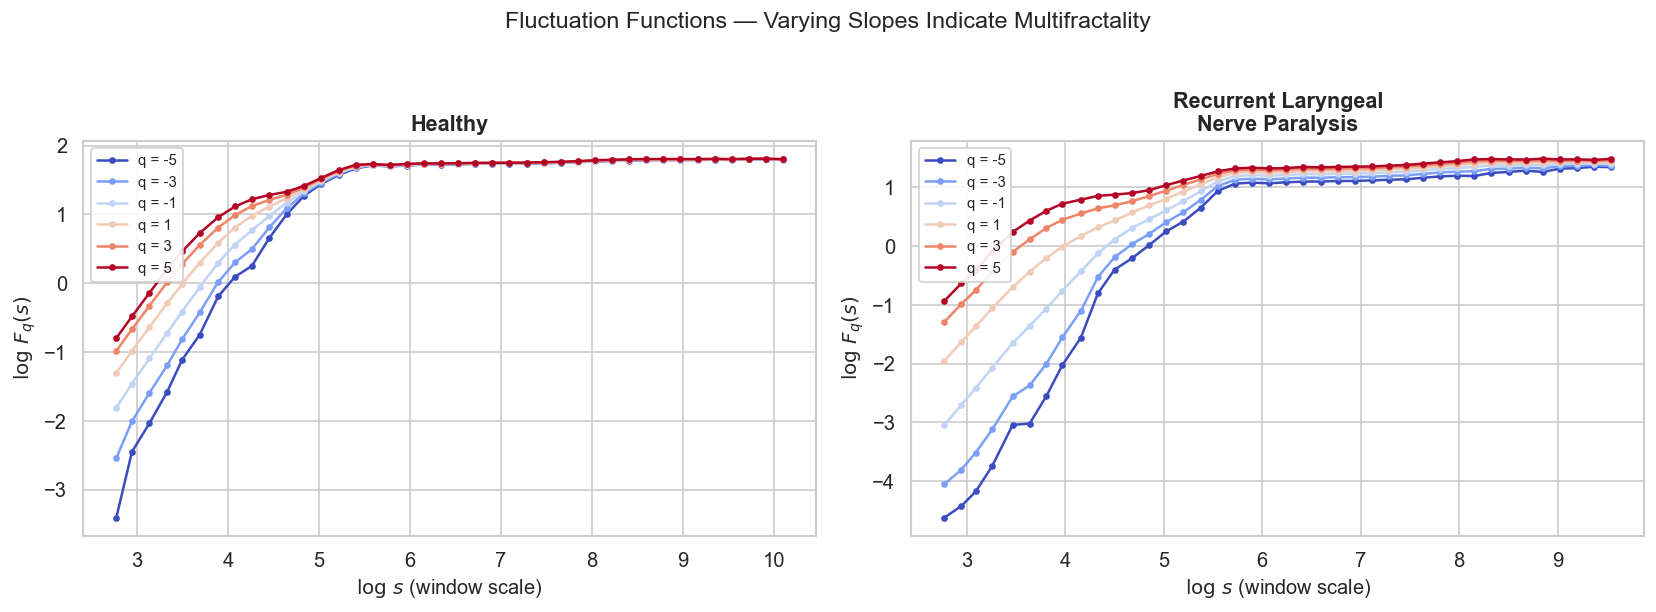

In [6]:
# ── Log-log F_q(s) plots ─────────────────────────────────────
q_display = [-5, -3, -1, 1, 3, 5]  # representative q values
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (label, res) in zip(axes, results.items()):
    lags = res["lags"]
    fq = res["fq"]
    q = res["q"]

    # Transpose if needed so shape is (scales, q_values)
    if fq.shape[0] != lags.shape[0]:
        fq = fq.T

    for q_val in q_display:
        idx = np.argmin(np.abs(q - q_val))
        curve = fq[:, idx]
        valid = (curve > 0) & np.isfinite(curve)
        if not np.any(valid):
            continue
        colour = cmap((q_val - Q_MIN) / (Q_MAX - Q_MIN))
        ax.plot(np.log(lags[valid]), np.log(curve[valid]),
                "o-", ms=3, lw=1.5, color=colour, label=f"q = {q[idx]:.0f}")

    ax.set_xlabel(r"$\log\,s$ (window scale)", fontsize=12)
    ax.set_ylabel(r"$\log\,F_q(s)$", fontsize=12)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

fig.suptitle("Fluctuation Functions — Varying Slopes Indicate Multifractality",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 6 — Generalised Hurst Exponent $h(q)$

This is the **central plot**. For a monofractal signal, $h(q)$ would be a **flat
horizontal line** — the same exponent regardless of which moment order $q$ you
examine. For a multifractal signal, $h(q)$ *decreases* with $q$:

- At **negative $q$**, the analysis emphasises *small* fluctuations → higher $h$
- At **positive $q$**, the analysis emphasises *large* fluctuations → lower $h$

The spread $\Delta h = h(q_{\min}) - h(q_{\max})$ measures the **degree of
multifractality**.

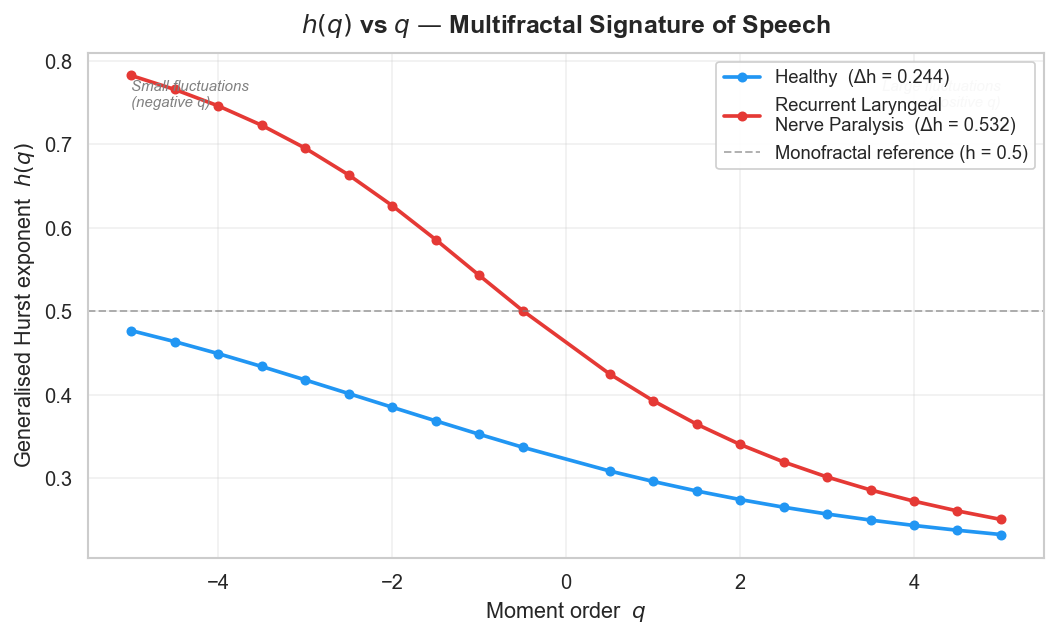

In [7]:
# ── h(q) vs q ────────────────────────────────────────────────
colours = {"Healthy": "#2196F3", "Recurrent Laryngeal\nNerve Paralysis": "#E53935"}

fig, ax = plt.subplots(figsize=(9, 5.5))

for label, res in results.items():
    q, hq = res["q"], res["hq"]
    finite = np.isfinite(hq)
    ax.plot(q[finite], hq[finite], "o-", ms=5, lw=2.2, color=colours[label],
            label=f"{label}  (Δh = {res['delta_h']:.3f})")

# Reference: monofractal would be a flat line
mono_h = 0.5  # example Hurst exponent for a monofractal signal
ax.axhline(mono_h, ls="--", lw=1.2, color="gray", alpha=0.6, label="Monofractal reference (h = 0.5)")

ax.set_xlabel("Moment order  $q$", fontsize=13)
ax.set_ylabel("Generalised Hurst exponent  $h(q)$", fontsize=13)
ax.set_title("$h(q)$ vs $q$ — Multifractal Signature of Speech",
             fontsize=15, fontweight="bold", pad=12)
ax.legend(fontsize=11, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.3)

# Annotate the key insight
ax.annotate("Small fluctuations\n(negative q)",
            xy=(Q_MIN, ax.get_ylim()[1] * 0.92), fontsize=9, color="gray",
            ha="left", style="italic")
ax.annotate("Large fluctuations\n(positive q)",
            xy=(Q_MAX, ax.get_ylim()[1] * 0.92), fontsize=9, color="gray",
            ha="right", style="italic")

fig.tight_layout()
plt.show()

## 7 — Multifractal Spectrum $f(\alpha)$

The **singularity spectrum** $f(\alpha)$ provides a complementary view. It is obtained
via the Legendre transform of $\tau(q)$:

$$\alpha = \frac{d\tau}{dq}, \qquad f(\alpha) = q \cdot \alpha - \tau(q)$$

- **Width** $\Delta\alpha = \alpha_{\max} - \alpha_{\min}$: broader spectrum → stronger multifractality
- **Peak location**: dominant scaling exponent
- **Asymmetry**: relative contribution of small vs large fluctuations

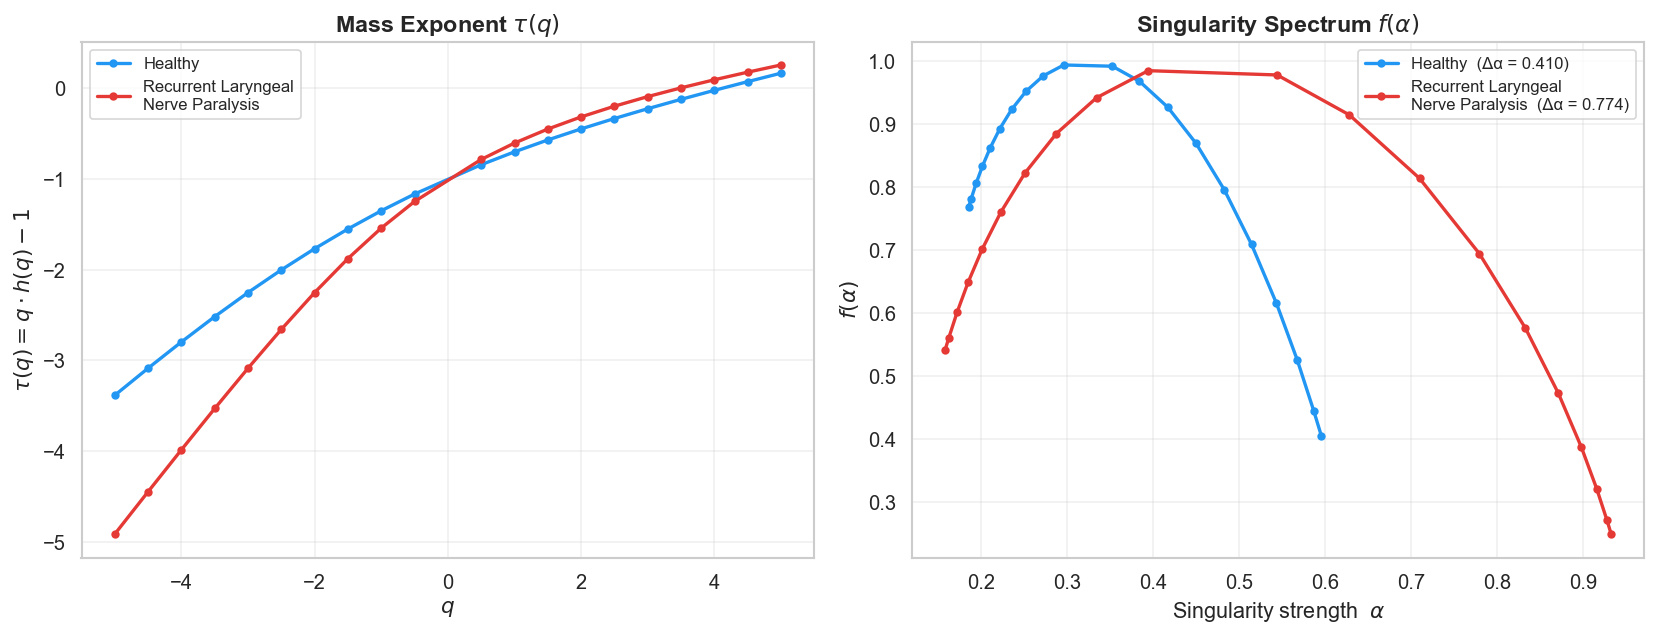

In [8]:
# ── Combined: τ(q) and f(α) ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# — τ(q) vs q —
for label, res in results.items():
    q, tau = res["q"], res["tau_q"]
    finite = np.isfinite(tau)
    ax1.plot(q[finite], tau[finite], "o-", ms=4, lw=2, color=colours[label], label=label)

ax1.set_xlabel("$q$", fontsize=13)
ax1.set_ylabel(r"$\tau(q) = q \cdot h(q) - 1$", fontsize=13)
ax1.set_title("Mass Exponent $\\tau(q)$", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# — f(α) vs α —
for label, res in results.items():
    alpha, fa = res["alpha"], res["f_alpha"]
    finite = np.isfinite(alpha) & np.isfinite(fa)
    alpha_w = float(np.nanmax(alpha) - np.nanmin(alpha))
    ax2.plot(alpha[finite], fa[finite], "o-", ms=4, lw=2, color=colours[label],
             label=f"{label}  (Δα = {alpha_w:.3f})")

ax2.set_xlabel(r"Singularity strength  $\alpha$", fontsize=13)
ax2.set_ylabel(r"$f(\alpha)$", fontsize=13)
ax2.set_title("Singularity Spectrum $f(\\alpha)$", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8 — Summary Table

Quantitative comparison of the multifractal descriptors for both signals:

In [9]:
# ── Summary table ─────────────────────────────────────────────
rows = []
for label, res in results.items():
    hq = res["hq"][np.isfinite(res["hq"])]
    alpha = res["alpha"][np.isfinite(res["alpha"])]
    rows.append({
        "Signal": label,
        "h(q) mean": f"{np.mean(hq):.4f}",
        "h(q) std": f"{np.std(hq):.4f}",
        "Δh (multifractal strength)": f"{res['delta_h']:.4f}",
        "Spectrum width Δα": f"{np.nanmax(alpha) - np.nanmin(alpha):.4f}",
        "Peak α": f"{alpha[np.nanargmax(res['f_alpha'][np.isfinite(res['f_alpha'])])]:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index("Signal")
summary_df

,h(q) mean,h(q) std,Δh (multifractal strength),Spectrum width Δα,Peak α
Signal,,,,,
Healthy,0.3367,0.0805,0.2443,0.4095,0.2965
Recurrent Laryngeal\nNerve Paralysis,0.4922,0.1870,0.5318,0.7741,0.3947


## Interpretation

Both healthy and pathological speech signals are clearly **multifractal** — the $h(q)$
curve is *not* constant, confirming that speech has complex, heterogeneous scaling
behaviour across time scales.

The key observations:

1. **$h(q)$ decreases with $q$** for both signals, confirming multifractality. A
   monofractal process (e.g., fractional Brownian motion) would show a flat $h(q)$.

2. **Δh (multifractal strength)** differs between healthy and pathological voices,
   meaning the *degree* of scaling heterogeneity varies with vocal health. This
   difference is what machine learning models can exploit for classification.

3. **The singularity spectrum** $f(\alpha)$ shows different widths and peak positions,
   providing additional discriminative features (spectrum width, peak location,
   asymmetry) that complement the raw $h(q)$ statistics.

These multifractal descriptors — alongside traditional acoustic features (MFCCs,
spectral measures, F0) — form the feature set used in our voice pathology
classification pipeline.